# Day 3: Supervised ML — Classification

<a target="_blank" href="https://colab.research.google.com/github/LuWidme/uk259/blob/main/demos/05_SupervisedML_Classification.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

**Duration:** 2–2.5 hours  
**Prerequisites:** Python basics, NumPy, Pandas, data preprocessing  

**Learning Objectives:**
- Understand what classification is and when to use it
- Implement K-Nearest Neighbors (KNN) from scratch
- Use Support Vector Machines (SVM) for classification
- Build and interpret Decision Trees
- Evaluate and compare different classification models

**Datasets Used:** Synthetic blobs, Breast Cancer Wisconsin, Iris, Titanic (`datasets/titanic.csv`)

---

## What is Classification?

**Classification** is a type of supervised learning where we predict **discrete class labels** (categories).

**Examples:**
- Email: **spam** or **not spam**
- Medical test: **malignant** or **benign**
- Flower species: **setosa**, **versicolor**, or **virginica**

**How it works:**
1. **Training:** Show the model many labeled examples ("this email is spam")
2. **Learning:** The model finds patterns that separate the classes
3. **Prediction:** Given a new, unseen example, the model assigns it to a class

**Classification vs. Regression:**

| | Classification | Regression |
|---|---|---|
| **Output** | Category (spam/not spam) | Number (price: €250,000) |
| **Examples** | Disease diagnosis, spam filter | House price, temperature |
| **Algorithms** | KNN, SVM, Decision Tree | Linear Regression |

In this notebook, we'll explore **three popular classification algorithms** and learn when to use each.

---

## Setup

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


---

## Part 1: K-Nearest Neighbors (KNN)

### How KNN Works

K-Nearest Neighbors is one of the simplest ML algorithms. It classifies a new data point by looking at its **k closest neighbors** and taking a majority vote.

**Analogy:** You move to a new neighborhood. To figure out if you'll like it, you ask the 5 nearest neighbors. If 4 out of 5 love it, you predict you'll love it too!

**Steps:**
1. Calculate the distance from the new point to **all** training points
2. Select the **k** closest neighbors
3. The most common class among those neighbors is the prediction

**Key parameter:** `k` — the number of neighbors to consider (typically odd to avoid ties)

### The Data

We'll start with a simple synthetic dataset of 2D blobs (clusters) so we can easily visualize what's happening.

Training samples: 400
Test samples: 100


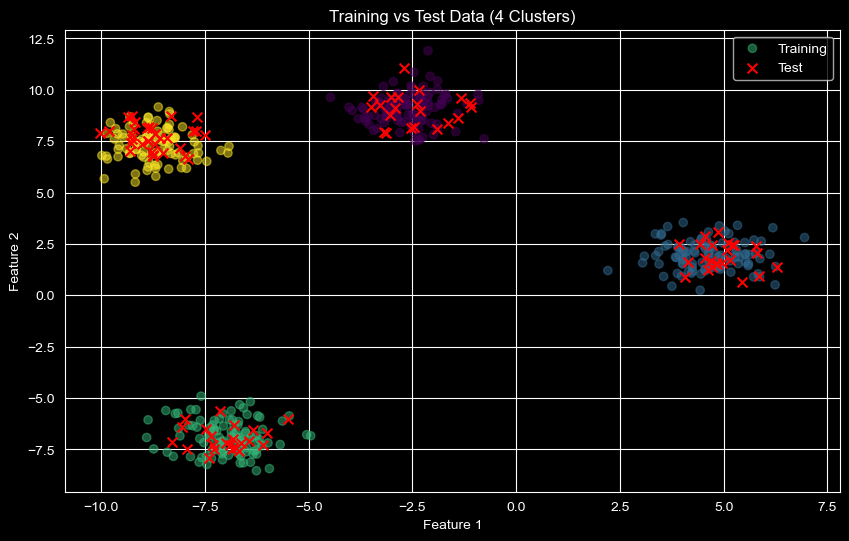

In [14]:
from sklearn.datasets import make_blobs

# Generate 4 clusters of points
data, labels = make_blobs(n_samples=500, centers=4, cluster_std=0.75, random_state=42)

# Split into training and test data
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.20, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, marker='o', alpha=0.5,
            cmap='viridis', label='Training')
plt.scatter(X_test[:, 0], X_test[:, 1], c='red', marker='x', s=50, label='Test')
plt.legend()
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Training vs Test Data (4 Clusters)')
plt.show()

### Task 1: Implement KNN from Scratch

Implement the K-Nearest Neighbor algorithm step by step.

**Hints:**
- Euclidean distance: `np.sqrt(np.sum((a - b)**2, axis=1))`
- Indices of smallest values: `np.argsort(array)[:k]`
- Most common label: `np.bincount(labels).argmax()`

In [15]:
def knn_predict(new_point, experience_data, experience_labels, k):
    """
    Predict the class of new_point using K-Nearest Neighbors.
    
    Parameters:
        new_point: array of shape (n_features,) - the point to classify
        experience_data: array of shape (n_samples, n_features) - training data
        experience_labels: array of shape (n_samples,) - training labels
        k: int - number of neighbors to consider
    
    Returns:
        predicted_class: int - the predicted class label
    """
    
    # Step 1: Calculate Euclidean distance to all training points
    distances = None  # TODO: np.sqrt(np.sum((experience_data - new_point)**2, axis=1))
    
    # Step 2: Find the indices of the k smallest distances
    k_nearest_indices = None  # TODO: np.argsort(distances)[:k]
    
    # Step 3: Get the labels of those k nearest neighbors
    k_nearest_labels = None  # TODO: experience_labels[k_nearest_indices]
    
    # Step 4: Return the most common label (majority vote)
    predicted_class = None  # TODO: np.bincount(k_nearest_labels).argmax()
    
    return predicted_class

In [16]:
# Test your KNN implementation
k = 5

print(f"Testing KNN implementation (k={k}):")
print(f"{'Point':<8} {'Predicted':<12} {'Actual':<10} {'Match'}")
print("-" * 40)

correct = 0
for i in range(10):
    prediction = knn_predict(X_test[i], X_train, y_train, k)
    actual = y_test[i]
    match = '✓' if prediction == actual else '✗'
    if prediction == actual:
        correct += 1
    print(f"{i:<8} {prediction:<12} {actual:<10} {match}")

print(f"\nAccuracy on sample: {correct}/10 ({correct/10:.0%})")

Testing KNN implementation (k=5):
Point    Predicted    Actual     Match
----------------------------------------


TypeError: unsupported format string passed to NoneType.__format__

### Using Scikit-Learn's KNN

Implementing from scratch helps understanding, but in practice we use optimized libraries.

Scikit-learn's `KNeighborsClassifier` is:
- Much faster (uses efficient data structures like KD-trees)
- Supports different distance metrics
- Has a consistent API shared with all other sklearn models

In [18]:
from sklearn.neighbors import KNeighborsClassifier

# Create, train, and evaluate
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {accuracy:.4f}")
print(f"Correctly classified: {sum(y_pred_knn == y_test)} / {len(y_test)}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 1.0000
Correctly classified: 100 / 100

Confusion Matrix:
[[21  0  0  0]
 [ 0 24  0  0]
 [ 0  0 23  0]
 [ 0  0  0 32]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        24
           2       1.00      1.00      1.00        23
           3       1.00      1.00      1.00        32

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



### Visualizing KNN Decision Boundaries

A decision boundary shows **where** the model switches from predicting one class to another. This helps us understand how the model "sees" the data.

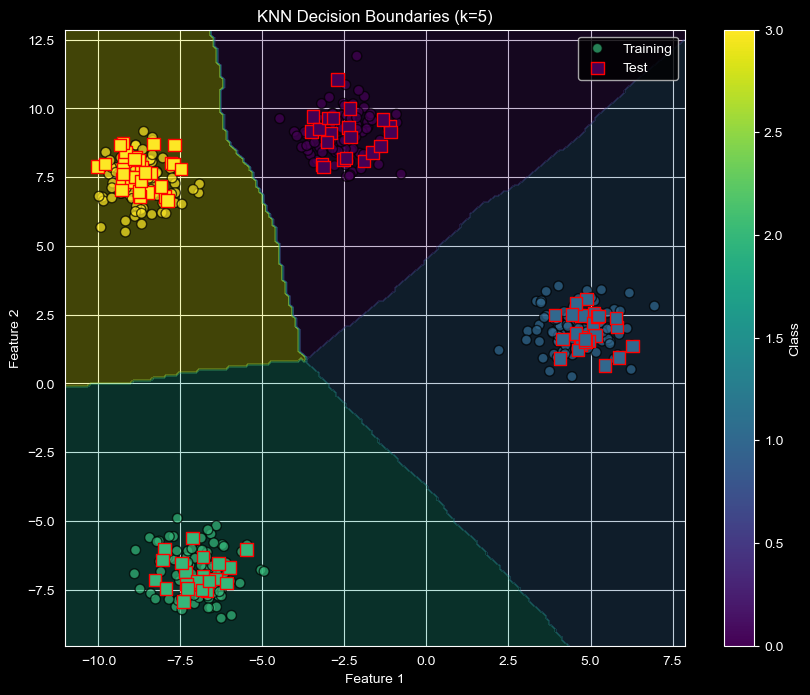

In [19]:
# Create a mesh grid covering the feature space
h = 0.1
x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict for every point in the grid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, marker='o',
            s=50, edgecolors='k', cmap='viridis', alpha=0.7, label='Training')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='s',
            s=80, edgecolors='red', cmap='viridis', label='Test')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'KNN Decision Boundaries (k={knn.n_neighbors})')
plt.legend()
plt.show()

---

## Part 2: Support Vector Machines (SVM)

### How SVM Works

SVM finds the **optimal boundary (hyperplane)** that separates classes with the **maximum margin**.

**Analogy:** Imagine two groups of points on a table. SVM draws the widest possible "road" between the groups. The wider the road, the more confident the separation.

**Key concepts:**
- **Hyperplane:** The decision boundary (a line in 2D, a plane in 3D)
- **Margin:** The distance between the hyperplane and the nearest points
- **Support vectors:** The points closest to the boundary (they "support" the hyperplane)
- **Kernel trick:** Transforms data to make it linearly separable in higher dimensions

**Key parameters:**
- `kernel`: `'linear'` (straight boundary), `'rbf'` (curved boundary, default), `'poly'` (polynomial)
- `C`: Controls trade-off between wide margin and correct classification

### Example: Breast Cancer Classification

We'll use the **Wisconsin Breast Cancer dataset** to classify tumors as malignant (0) or benign (1). This is a real medical dataset with 30 features computed from cell nucleus images.

In [ ]:
from sklearn import svm, datasets

# Load breast cancer dataset
cancer = datasets.load_breast_cancer(as_frame=True)

X_cancer = cancer.data
y_cancer = cancer.target

print(f"Dataset: {cancer.data.shape[0]} samples, {cancer.data.shape[1]} features")
print(f"\nTarget classes:")
print(f"  0 = Malignant: {sum(y_cancer == 0)}")
print(f"  1 = Benign:    {sum(y_cancer == 1)}")
print(f"\nFirst 5 feature names: {list(cancer.feature_names[:5])}")

In [ ]:
# Split data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.25, stratify=y_cancer, random_state=42
)

# Train SVM with linear kernel
svm_clf = svm.SVC(kernel='linear')
svm_clf.fit(X_train_c, y_train_c)

# Predict and evaluate
y_pred_svm = svm_clf.predict(X_test_c)

print(f"SVM Accuracy: {accuracy_score(y_test_c, y_pred_svm):.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test_c, y_pred_svm))
print(f"\nClassification Report:")
print(classification_report(y_test_c, y_pred_svm, target_names=['Malignant', 'Benign']))

### Reading the Confusion Matrix

```
                 Predicted
              Malignant  Benign
Actual  Mal [   TN        FP  ]
        Ben [   FN        TP  ]
```

- **True Negatives (TN):** Malignant, correctly classified
- **True Positives (TP):** Benign, correctly classified
- **False Positives (FP):** Malignant predicted as benign (dangerous!)
- **False Negatives (FN):** Benign predicted as malignant (unnecessary worry)

In medical contexts, **False Negatives are especially dangerous** — missing a malignant tumor.

### Visualizing the SVM Decision Boundary

To visualize SVM in 2D, we'll create a simple synthetic dataset.

In [22]:
from sklearn.datasets import make_classification
from sklearn.svm import SVC

# Create a 2D dataset for visualization
X_2d, y_2d = make_classification(
    n_samples=2000, n_features=2, n_informative=2, n_redundant=0,
    n_classes=2, random_state=11
)

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y_2d, test_size=0.3, stratify=y_2d, random_state=32
)

# Train SVM
svc_model = SVC(kernel='linear', random_state=32)
svc_model.fit(X_train_2d, y_train_2d)

print(f"Training accuracy: {svc_model.score(X_train_2d, y_train_2d):.4f}")
print(f"Test accuracy:     {svc_model.score(X_test_2d, y_test_2d):.4f}")

Training accuracy: 0.8779
Test accuracy:     0.8733


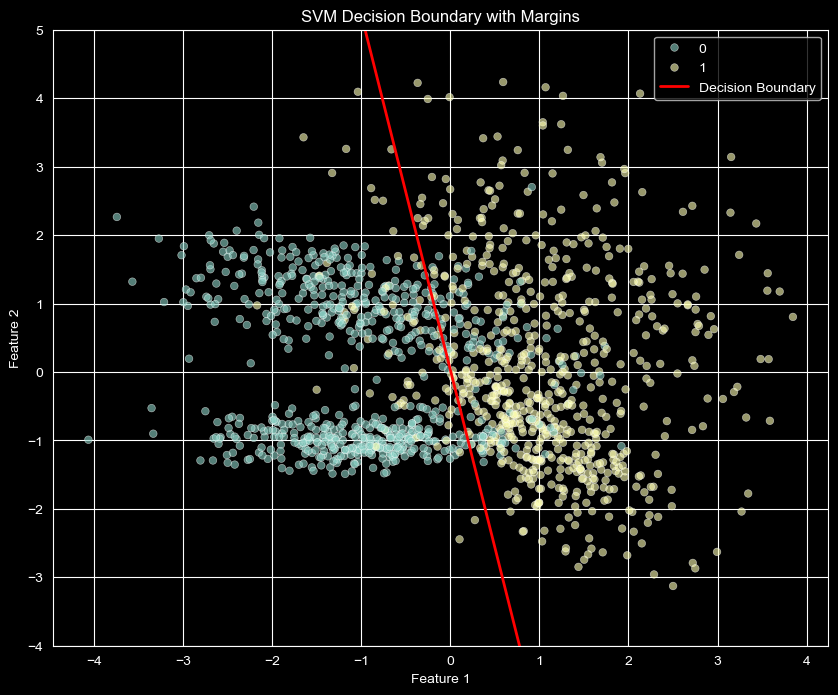

In [32]:
plt.figure(figsize=(10, 8))

# Plot training data
sns.scatterplot(x=X_train_2d[:, 0], y=X_train_2d[:, 1], hue=y_train_2d, s=30, alpha=0.6)
plt.ylim((-4,5))
# Extract and plot the decision boundary
w = svc_model.coef_[0]
b = svc_model.intercept_[0]
x_points = np.linspace(X_train_2d[:, 0].min(), X_train_2d[:, 0].max(), 100)
y_points = -(w[0] / w[1]) * x_points - b / w[1]

plt.plot(x_points, y_points, 'r-', linewidth=2, label='Decision Boundary')


plt.title('SVM Decision Boundary with Margins')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

The **solid red line** is the decision boundary. The **dashed lines** show the margin. SVM maximizes the distance between these margin lines.

---

## Part 3: Decision Trees

### How Decision Trees Work

Decision Trees classify data by asking a series of **yes/no questions** about the features.

**Analogy:** It's like playing 20 Questions. The tree asks: "Is flipper length > 206mm?" If yes, go left. If no, go right. Keep asking until you reach a final answer.

**Structure:**
- **Root node:** First question (best feature to split on)
- **Internal nodes:** Follow-up questions
- **Leaf nodes:** Final predictions (class labels)

**Key advantage:** Decision Trees are **easy to interpret** — you can trace exactly why a prediction was made!

**Key parameters:**
- `max_depth`: How deep the tree can grow (controls overfitting)
- `criterion`: How to measure split quality (`'gini'` or `'entropy'`)

### Example: Iris Classification

The **Iris dataset** is a classic ML dataset with measurements of 150 iris flowers from 3 species.

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

print(f"Features: {iris.feature_names}")
print(f"Classes: {list(iris.target_names)}")
print(f"Samples: {len(X_iris)}")

iris_df = pd.DataFrame(X_iris, columns=iris.feature_names)
iris_df['species'] = [iris.target_names[i] for i in y_iris]
iris_df.head()

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Samples: 150


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [34]:
# Split the data
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

# Train a Decision Tree
dt_clf = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
dt_clf.fit(X_train_iris, y_train_iris)

# Evaluate
y_pred_dt = dt_clf.predict(X_test_iris)

print(f"Training accuracy: {dt_clf.score(X_train_iris, y_train_iris):.4f}")
print(f"Test accuracy:     {dt_clf.score(X_test_iris, y_test_iris):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_iris, y_pred_dt, target_names=iris.target_names))

Training accuracy: 0.9810
Test accuracy:     0.9778

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



### Visualizing the Decision Tree

One of the biggest advantages of decision trees: you can **see** exactly how the model makes decisions.

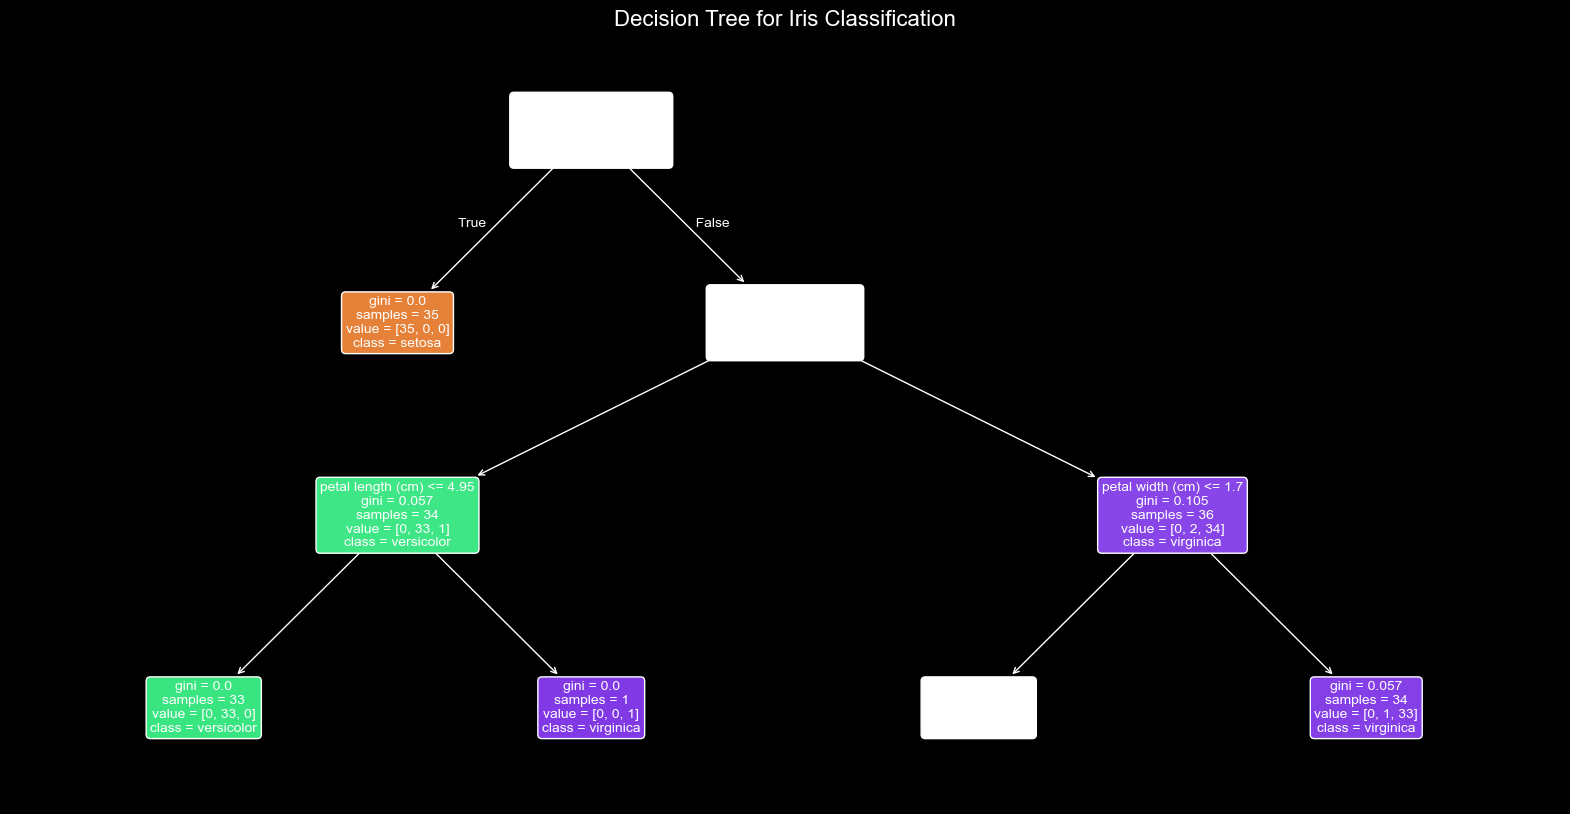

Reading the tree:
- Each box shows: the question (top), sample count, and predicted class
- Left branch = True (condition met), Right branch = False
- Colors indicate the predicted class


In [35]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_clf,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree for Iris Classification", fontsize=16)
plt.show()

print("Reading the tree:")
print("- Each box shows: the question (top), sample count, and predicted class")
print("- Left branch = True (condition met), Right branch = False")
print("- Colors indicate the predicted class")

### Feature Importance

Decision trees can tell us which features are **most useful** for making predictions.

Feature Importances:
          Feature  Importance
petal length (cm)    0.550877
 petal width (cm)    0.449123
 sepal width (cm)    0.000000
sepal length (cm)    0.000000


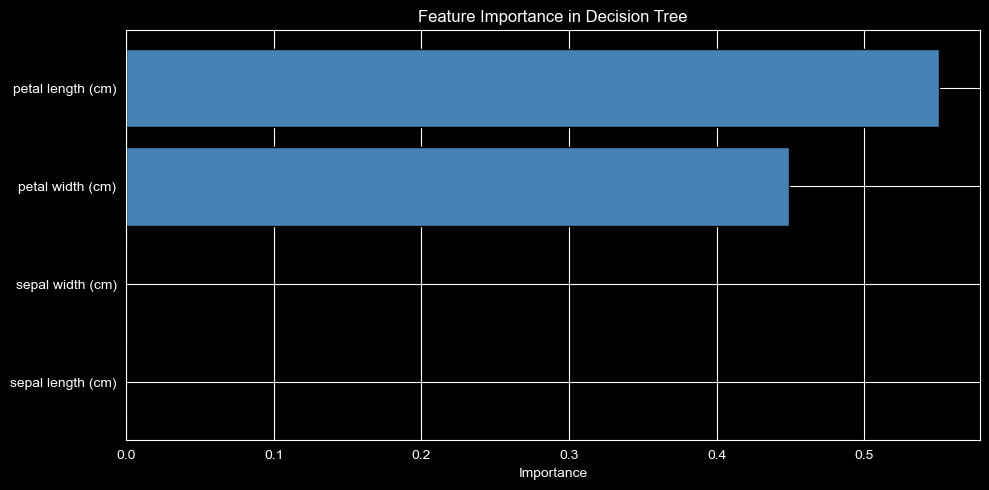

In [36]:
importances = dt_clf.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Feature Importances:")
print(feat_imp.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue', edgecolor='black')
plt.xlabel('Importance')
plt.title('Feature Importance in Decision Tree')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Understanding Overfitting in Decision Trees

**Overfitting** happens when a model learns the training data "too well" — including noise. It performs great on training data but poorly on new data.

Decision trees are **especially prone to overfitting** when they grow too deep. Let's see this in action.

Depth=   1:  Train=0.6667  Test=0.6667  Gap=0.0000
Depth=   2:  Train=0.9714  Test=0.8889  Gap=0.0825
Depth=   3:  Train=0.9810  Test=0.9778  Gap=0.0032
Depth=   5:  Train=1.0000  Test=0.9333  Gap=0.0667
Depth=  10:  Train=1.0000  Test=0.9333  Gap=0.0667
Depth=None:  Train=1.0000  Test=0.9333  Gap=0.0667


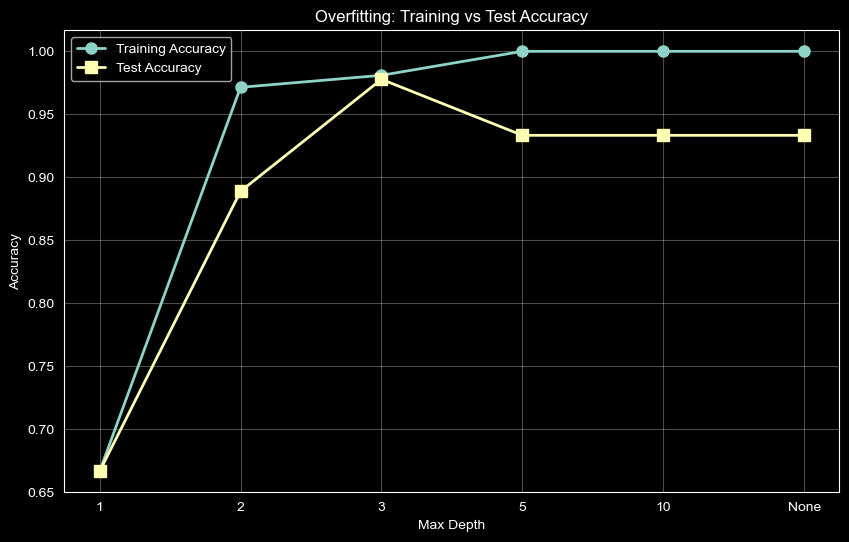


Key insight: When the gap between train and test accuracy grows,
the model is overfitting — memorizing training data instead of learning patterns.


In [37]:
depths = [1, 2, 3, 5, 10, None]  # None = unlimited depth
train_scores = []
test_scores = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_iris, y_train_iris)
    
    train_acc = dt.score(X_train_iris, y_train_iris)
    test_acc = dt.score(X_test_iris, y_test_iris)
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    
    depth_str = str(depth) if depth is not None else 'None'
    gap = train_acc - test_acc
    print(f"Depth={depth_str:>4s}:  Train={train_acc:.4f}  Test={test_acc:.4f}  Gap={gap:.4f}")

# Visualize
plt.figure(figsize=(10, 6))
x_labels = [str(d) if d is not None else 'None' for d in depths]
plt.plot(x_labels, train_scores, 'o-', label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(x_labels, test_scores, 's-', label='Test Accuracy', linewidth=2, markersize=8)
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Overfitting: Training vs Test Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nKey insight: When the gap between train and test accuracy grows,")
print("the model is overfitting — memorizing training data instead of learning patterns.")

---

## Part 4: Model Comparison

Now let's compare all three algorithms side-by-side on the same dataset.

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM (linear)': SVC(kernel='linear', random_state=42),
    'SVM (rbf)': SVC(kernel='rbf', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train_iris, y_train_iris)
    y_pred = model.predict(X_test_iris)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_iris, y_pred),
        'Precision': precision_score(y_test_iris, y_pred, average='weighted'),
        'Recall': recall_score(y_test_iris, y_pred, average='weighted'),
        'F1-Score': f1_score(y_test_iris, y_pred, average='weighted')
    })

comparison_df = pd.DataFrame(results).round(4)
print("Model Comparison on Iris Dataset:")
print(comparison_df.to_string(index=False))

Model Comparison on Iris Dataset:
        Model  Accuracy  Precision  Recall  F1-Score
    KNN (k=5)    0.9778     0.9792  0.9778    0.9778
 SVM (linear)    1.0000     1.0000  1.0000    1.0000
    SVM (rbf)    0.9556     0.9556  0.9556    0.9556
Decision Tree    0.9778     0.9792  0.9778    0.9778


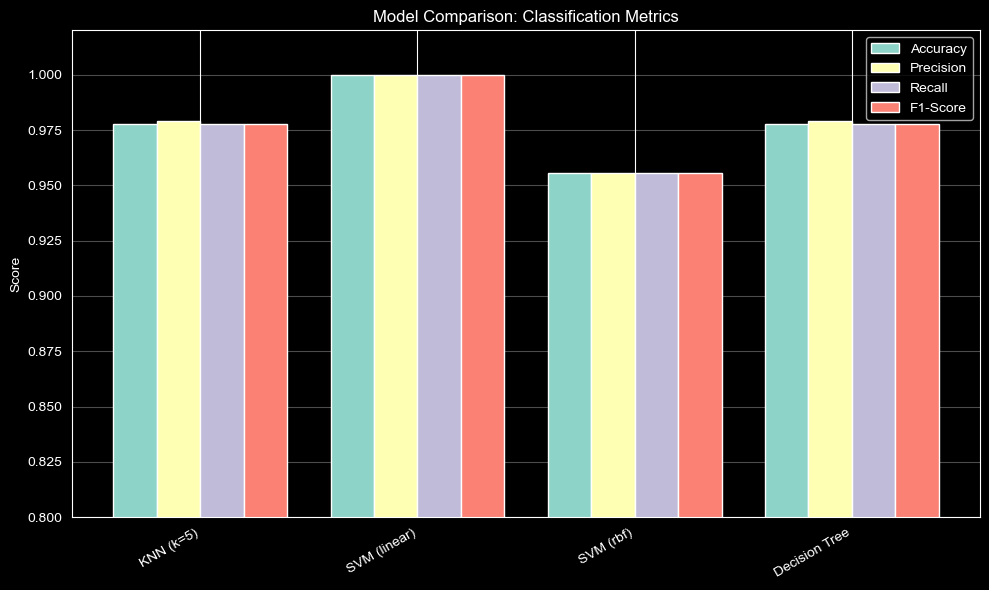

In [39]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(comparison_df))
width = 0.2

for i, metric in enumerate(metrics):
    offset = width * (i - 1.5)
    ax.bar(x + offset, comparison_df[metric], width, label=metric)

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Classification Metrics')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=30, ha='right')
ax.legend()
ax.set_ylim([0.8, 1.02])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### When to Use Which Algorithm?

| Algorithm | Best For | Pros | Cons |
|-----------|----------|------|------|
| **KNN** | Small datasets, simple problems | Simple, no training | Slow predictions, sensitive to scale |
| **SVM** | High-dimensional data, clear margins | Powerful, works in high dimensions | Slow on large datasets, hard to interpret |
| **Decision Tree** | When interpretability matters | Easy to understand, handles mixed data | Prone to overfitting |

**General advice:**
1. Start simple (Decision Tree or KNN)
2. Try multiple models and compare
3. Always validate on test data
4. **Scale your features** for KNN and SVM (use `StandardScaler`)

---

## Part 5: Exercises

### Exercise 1: Titanic Survival Prediction

**Scenario:** Predict which passengers survived the Titanic disaster based on their characteristics.

**Tasks:**
1. Load the Titanic dataset
2. Preprocess the data (handle missing values, encode categorical features)
3. Train all three classifiers (KNN, SVM, Decision Tree)
4. Compare their performance

**Hints:**
- Use `pd.get_dummies()` to encode categorical columns like 'Sex'
- Drop columns with too many missing values (e.g., 'Cabin')
- Fill remaining missing values with the median: `df.fillna(df.median())`
- Use `StandardScaler` before KNN and SVM

In [8]:
from sklearn.preprocessing import StandardScaler

# Step 1: Load the Titanic dataset
titanic = pd.read_csv('../datasets/titanic.csv')
print(f"Dataset shape: {titanic.shape}")
print(f"\nColumns: {list(titanic.columns)}")
print(f"\nMissing values:")
print(titanic.isnull().sum())
titanic.head()

Dataset shape: (887, 8)

Columns: ['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Fare']

Missing values:
Survived                   0
Pclass                     0
Name                       1
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
dtype: int64


,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [9]:
# Step 2: Preprocess the data

# TODO: Select useful features and the target variable 'Survived'
# Suggested features: 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare'
features = None  # TODO: list of feature column names

# TODO: Create a working copy with only the needed columns
df = None  # TODO: titanic[features + ['Survived']].copy()

# TODO: Handle missing values
# Hint: df['Age'].fillna(df['Age'].median(), inplace=True)

# TODO: Encode categorical variables
# Hint: df = pd.get_dummies(df, columns=['Sex'], drop_first=True)

# TODO: Define X (features) and y (target)
X_titanic = None  # TODO: all columns except 'Survived'
y_titanic = None  # TODO: the 'Survived' column

# TODO: Split into train/test
# Hint: train_test_split(X_titanic, y_titanic, test_size=0.25, random_state=42, stratify=y_titanic)

In [10]:
# Step 3 & 4: Train models and compare

# TODO: Scale features (important for KNN and SVM!)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_t)
# X_test_scaled = scaler.transform(X_test_t)

# TODO: Train KNN, SVM, and Decision Tree on the Titanic data
# TODO: Print accuracy and classification report for each
# TODO: Which model performs best? Why?

---

### Exercise 2: KNN Parameter Tuning

**Task:** Explore how the number of neighbors `k` affects KNN performance on the Iris dataset.

1. Try k values from 1 to 15
2. Record training and test accuracy for each
3. Plot the results
4. Which `k` gives the best test accuracy?

In [11]:
# TODO: Try different k values for KNN
k_values = range(1, 16)
train_accuracies = None  # TODO: list of training accuracies for each k
test_accuracies = None   # TODO: list of test accuracies for each k

# TODO: Loop over k_values
# For each k:
#   1. Create KNeighborsClassifier(n_neighbors=k)
#   2. Fit on X_train_iris, y_train_iris
#   3. Record training and test accuracy

# TODO: Plot training vs test accuracy for each k
# TODO: Print the best k value

---

### Exercise 3: SVM Kernel Comparison

**Task:** Compare different SVM kernels on the breast cancer dataset.

1. Train SVM with kernels: `'linear'`, `'rbf'`, `'poly'`
2. Compare accuracy for each kernel
3. Which kernel works best for this dataset?

In [12]:
# TODO: Compare SVM kernels on the breast cancer dataset
kernels = ['linear', 'rbf', 'poly']

# TODO: For each kernel:
#   1. Create SVC(kernel=kernel)
#   2. Fit on X_train_c, y_train_c (breast cancer data from Part 2)
#   3. Print accuracy on test set
# TODO: Which kernel performs best?

---

## Summary

In this notebook you learned:

✓ What classification is and how it differs from regression  
✓ How K-Nearest Neighbors works (and how to implement it from scratch)  
✓ How Support Vector Machines find optimal decision boundaries  
✓ How Decision Trees make interpretable classification decisions  
✓ How to evaluate models using accuracy, precision, recall, and F1-score  
✓ How to compare multiple models and choose the best one  
✓ The concept of overfitting and how to detect it  

### Key Takeaways

1. **No single best algorithm** — always try multiple models
2. **Evaluate on test data** — training accuracy alone is misleading
3. **Scale your features** for distance-based methods (KNN, SVM)
4. **Watch for overfitting** — compare train vs. test performance
5. **Decision Trees are interpretable** — great when you need to explain predictions

### What's Next?

- **Linear Regression:** Predicting continuous values instead of categories
- **Ensemble methods:** Random Forests combine many Decision Trees for better accuracy
- **Cross-validation:** More robust model evaluation
- **Neural Networks:** Deep learning for complex classification tasks

---